# Digital Wellbeing Score Prediction Using Random Forest

## Machine Learning Mini Project

### Problem Statement
Digital habits such as screen time, social-media usage, app switching and notifications can be considered together with sleep, focus, mood and anxiety to estimate a person's overall digital wellbeing.

### Aim
To develop a **Random Forest Regressor** that predicts a **Digital Wellbeing Score from 0 to 100** and identifies the features that most influence the prediction.

> **Dataset note:** This repository contains a reproducible 500-row educational dataset following the feature structure of the public Kaggle dataset *Mental Health and Digital Behavior (2020–2024)*. The public source describes its data as simulated. The included CSV is generated locally so the project can run without Kaggle credentials.

## 1. Import Required Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

In [2]:
DATA_PATH = "digital_wellbeing_dataset.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        "digital_wellbeing_dataset.csv was not found. "
        "Keep the CSV in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
df.head()

Dataset loaded successfully!
Dataset shape: (500, 9)


,daily_screen_time_min,num_app_switches,sleep_hours,notification_count,social_media_time_min,focus_score,mood_score,anxiety_level,digital_wellbeing_score
0,404.4,64,6.9,73,101.9,7.3,8.2,3.7,70.8
1,296.8,59,6.1,71,93.4,7.3,7.7,5.0,65.0
2,440.0,43,6.5,130,137.4,6.7,8.0,5.5,59.5
3,455.2,35,7.8,100,130.1,7.0,6.2,3.5,71.1
4,223.9,20,7.0,84,63.8,8.8,8.0,3.0,83.3


## 3. Dataset Information

In [3]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   daily_screen_time_min    500 non-null    float64
 1   num_app_switches         500 non-null    int64  
 2   sleep_hours              500 non-null    float64
 3   notification_count       500 non-null    int64  
 4   social_media_time_min    500 non-null    float64
 5   focus_score              500 non-null    float64
 6   mood_score               500 non-null    float64
 7   anxiety_level            500 non-null    float64
 8   digital_wellbeing_score  500 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 35.3 KB
None

Missing values:
daily_screen_time_min      0
num_app_switches           0
sleep_hours                0
notification_count         0
social_media_time_min      0
focus_score                0
mood_score                 0
anxiety_level             

## 4. Statistical Summary

In [4]:
df.describe().round(2)

,daily_screen_time_min,num_app_switches,sleep_hours,notification_count,social_media_time_min,focus_score,mood_score,anxiety_level,digital_wellbeing_score
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,378.96,49.55,6.99,85.25,120.03,6.88,7.23,4.25,64.26
std,76.77,10.14,1.22,29.96,40.61,1.05,0.97,1.27,12.52
min,180.00,20.00,3.50,10.00,20.00,4.20,4.20,1.00,26.40
25%,326.68,43.00,6.20,66.00,92.18,6.10,6.60,3.30,55.05
50%,380.25,50.00,7.00,86.00,121.50,6.90,7.20,4.30,64.50
75%,427.00,56.00,7.80,105.00,146.40,7.60,7.90,5.10,73.05
max,613.10,82.00,10.00,177.00,234.30,9.80,9.80,8.60,97.80


## 5. Digital Wellbeing Score Distribution

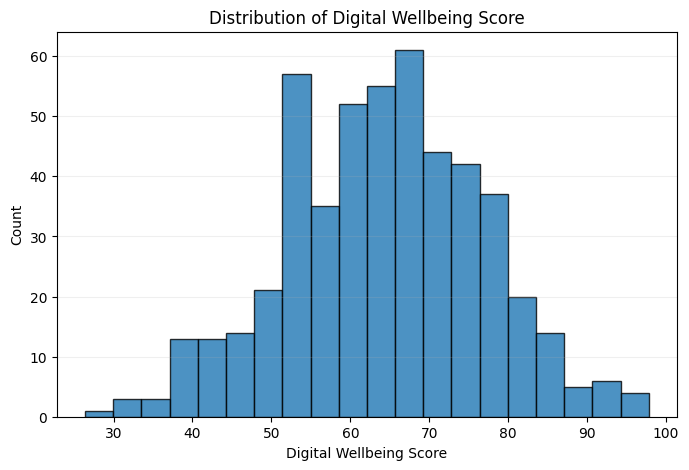

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(df["digital_wellbeing_score"], bins=20, edgecolor="black", alpha=0.8)
plt.title("Distribution of Digital Wellbeing Score")
plt.xlabel("Digital Wellbeing Score")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.2)
plt.show()

## 6. Correlation Analysis

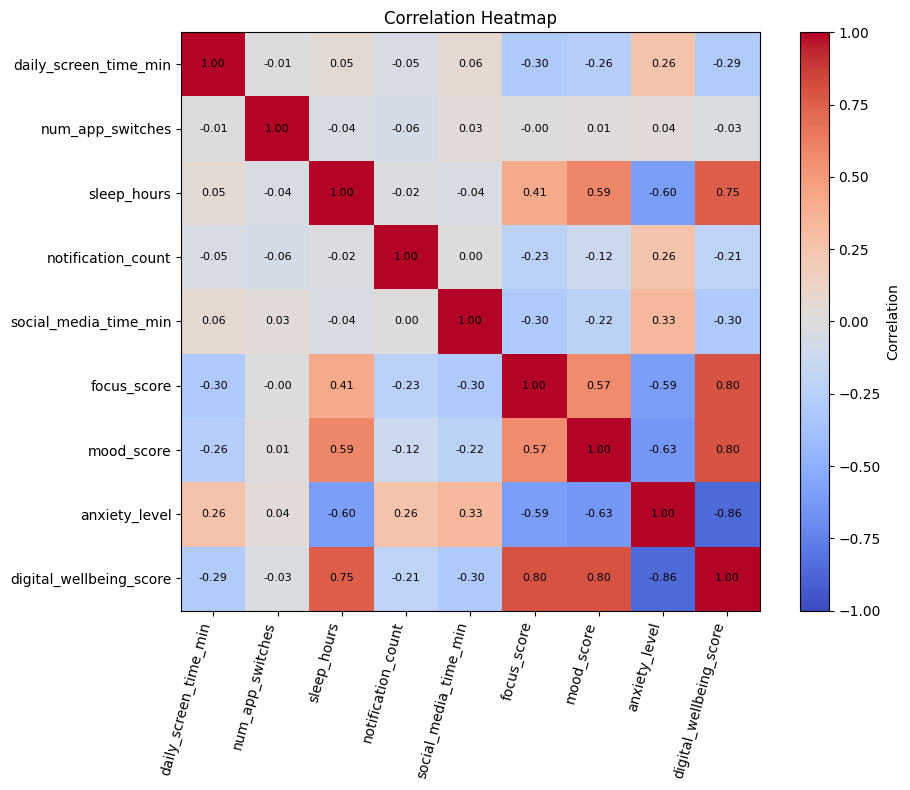

In [6]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=75, ha="right")
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 7. Split Input and Output

In [7]:
X = df.drop(columns=["digital_wellbeing_score"])
y = df["digital_wellbeing_score"]

print("Input features:")
for feature in X.columns:
    print("-", feature)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Input features:
- daily_screen_time_min
- num_app_switches
- sleep_hours
- notification_count
- social_media_time_min
- focus_score
- mood_score
- anxiety_level

X shape: (500, 8)
y shape: (500,)


## 8. Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (400, 8)
Testing data : (100, 8)


## 9. Train Random Forest Regressor

In [9]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## 10. Make Predictions

In [10]:
y_pred = rf_model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Score": y_test.values[:10],
    "Predicted Score": np.round(y_pred[:10], 2)
})

comparison

,Actual Score,Predicted Score
0,72.8,75.73
1,52.8,51.93
2,70.7,70.09
3,53.2,56.66
4,62.5,63.10
5,39.8,43.59
6,66.3,65.71
7,57.7,56.26
8,65.2,64.71
9,53.8,55.39


## 11. Model Evaluation

In [11]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Variance Explained: {r2 * 100:.2f}%")

Mean Absolute Error (MAE): 2.45
Root Mean Squared Error (RMSE): 3.13
R² Score: 0.9286
Variance Explained: 92.86%


## 12. Actual vs Predicted Scores

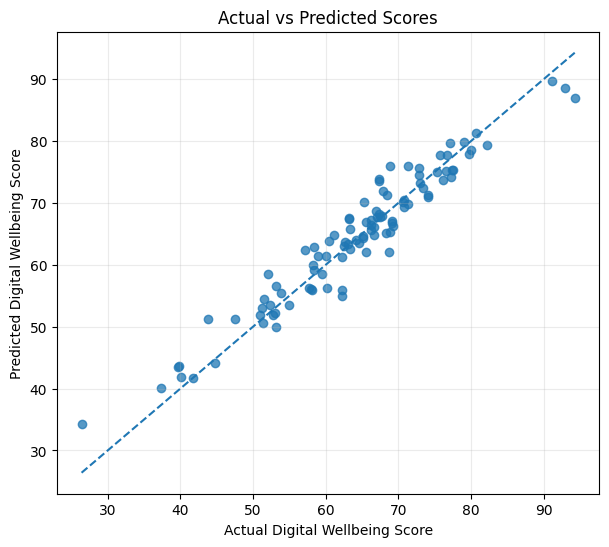

In [12]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.75)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Digital Wellbeing Score")
plt.ylabel("Predicted Digital Wellbeing Score")
plt.title("Actual vs Predicted Scores")
plt.grid(alpha=0.25)
plt.show()

## 13. Feature Importance

                 Feature  Importance
7          anxiety_level    0.606537
5            focus_score    0.171789
6             mood_score    0.108659
2            sleep_hours    0.085901
0  daily_screen_time_min    0.008743
4  social_media_time_min    0.006791
3     notification_count    0.006040
1       num_app_switches    0.005540


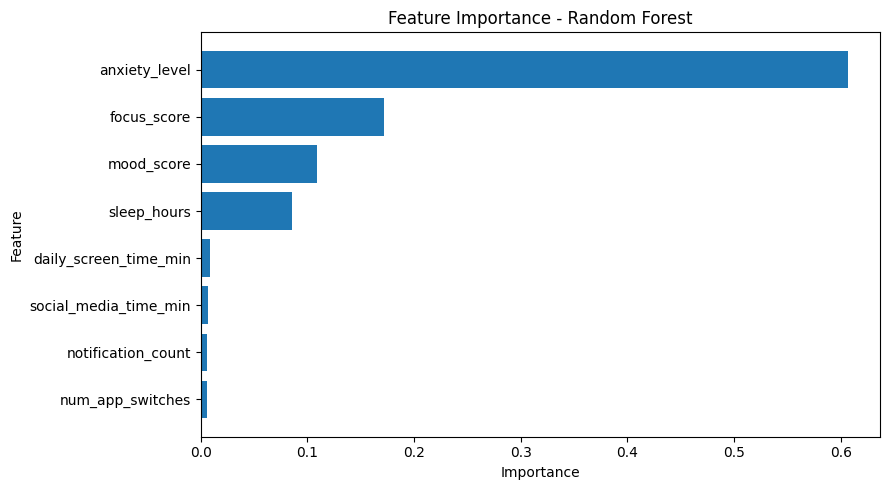

In [13]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=True)

print(importance_df.sort_values("Importance", ascending=False))

plt.figure(figsize=(9, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

## 14. Predict Score for a New User

In [14]:
def predict_digital_wellbeing(
    daily_screen_time_min,
    num_app_switches,
    sleep_hours,
    notification_count,
    social_media_time_min,
    focus_score,
    mood_score,
    anxiety_level
):
    user = pd.DataFrame([{
        "daily_screen_time_min": daily_screen_time_min,
        "num_app_switches": num_app_switches,
        "sleep_hours": sleep_hours,
        "notification_count": notification_count,
        "social_media_time_min": social_media_time_min,
        "focus_score": focus_score,
        "mood_score": mood_score,
        "anxiety_level": anxiety_level
    }])

    predicted_score = float(rf_model.predict(user)[0])
    predicted_score = float(np.clip(predicted_score, 0, 100))

    if predicted_score >= 70:
        level = "Good"
    elif predicted_score >= 50:
        level = "Moderate"
    else:
        level = "Needs Attention"

    return round(predicted_score, 2), level


score, level = predict_digital_wellbeing(
    daily_screen_time_min=360,
    num_app_switches=48,
    sleep_hours=7.5,
    notification_count=75,
    social_media_time_min=100,
    focus_score=7.5,
    mood_score=8.0,
    anxiety_level=4.0
)

print("Predicted Digital Wellbeing Score:", score)
print("Wellbeing Level:", level)

Predicted Digital Wellbeing Score: 71.06
Wellbeing Level: Good


## 15. Save the Trained Model

In [15]:
joblib.dump(rf_model, "digital_wellbeing_random_forest.joblib")
print("Model saved successfully!")

Model saved successfully!


## Result

The Random Forest Regressor successfully predicted the Digital Wellbeing Score using digital behavior and wellbeing features. The model was evaluated using **MAE, RMSE and R² score**, while feature importance was used to identify the variables that contributed most to the predictions.

## Conclusion

This project demonstrates the use of Random Forest regression for digital wellbeing score prediction. It is an **educational machine learning project** and should not be treated as a medical or psychological diagnostic system.